# EDA 2.0: Phân tích Hình thái Học (Morphology) và Khai phá Lỗ hổng Quang phổ màu bằng Face Segmentation

> [!WARNING]
> **Tồn đọng kỹ thuật:** Nếu tính phổ màu trên toàn bộ bức ảnh (kể cả phông nền), nhiễu loạn từ hậu cảnh sẽ che lấp những sai sót ánh sáng vi mô của GAN.

**Giải pháp:**
1. Dùng `MediaPipe Tasks API` để bóc tách chính xác lớp mặt nạ đa giác (Face Mesh Hull) ôm sát bề mặt da.
2. Tính toán kênh màu **YCbCr** (Không gian màu tách biệt độ chói (Y) và sắc độ (Cb, Cr)).
3. Đo lường chính xác khoảng cách phân bố màu bằng **Bhattacharyya Distance**.


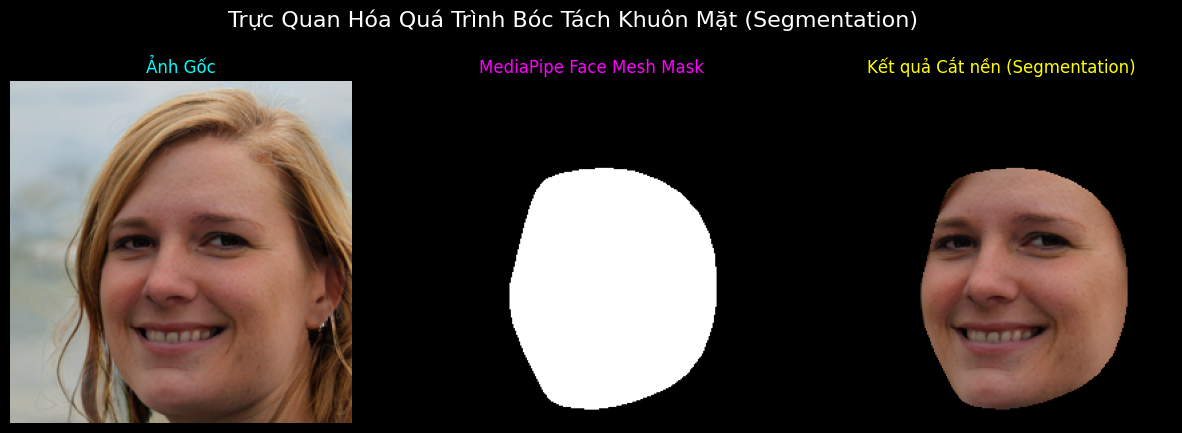

In [1]:
import cv2
import os
import urllib.request
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

plt.style.use('dark_background')

# Tải model MediaPipe
model_path = 'face_landmarker.task'
if not os.path.exists(model_path):
    urllib.request.urlretrieve('https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task', model_path)

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceLandmarkerOptions(base_options=base_options, num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

base_dir = "../data"
real_images = [f for f in glob(os.path.join(base_dir, '**', '*.*'), recursive=True) if 'real' in f.lower() and f.lower().endswith(('.png', '.jpg'))]
fake_images = [f for f in glob(os.path.join(base_dir, '**', '*.*'), recursive=True) if 'fake' in f.lower() and f.lower().endswith(('.png', '.jpg'))]

np.random.seed(42)
sample_size = 2000
real_sample = np.random.choice(real_images, min(sample_size, len(real_images)), replace=False) if len(real_images) > 0 else []
fake_sample = np.random.choice(fake_images, min(sample_size, len(fake_images)), replace=False) if len(fake_images) > 0 else []

def process_segmented_face(img_path):
    img = cv2.imread(img_path)
    if img is None: return None, None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    detection_result = detector.detect(mp_image)
    
    if not detection_result.face_landmarks:
        return img_rgb, None, None
        
    h, w, _ = img.shape
    points = np.array([[int(l.x * w), int(l.y * h)] for l in detection_result.face_landmarks[0]], dtype=np.int32)
    hull = cv2.convexHull(points)
    
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(mask, hull, 255)
    
    segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    return img_rgb, mask, segmented

# Trực quan hóa Mask Extraction
if len(fake_sample) > 0:
    img_og, mask, img_seg = process_segmented_face(fake_sample[0])
    if mask is not None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img_og); axes[0].set_title('Ảnh Gốc', color='cyan')
        axes[1].imshow(mask, cmap='gray'); axes[1].set_title('MediaPipe Face Mesh Mask', color='magenta')
        axes[2].imshow(img_seg); axes[2].set_title('Kết quả Cắt nền (Segmentation)', color='yellow')
        for ax in axes: ax.axis('off')
        plt.suptitle("Trực Quan Hóa Quá Trình Bóc Tách Khuôn Mặt (Segmentation)", fontsize=16)
        plt.show()


### Đo lường sự sai lệch Quang phổ màu (Bhattacharyya Distance)
Thuật toán so sánh đồ thị phân bố bằng khoảng cách Bhattacharyya. Nếu `D(B) = 0`, hai phân bố hoàn toàn trùng khớp. Càng tiến về 1, độ sai lệch càng lớn.


Computing YCrCb: 100%|██████████| 2000/2000 [00:20<00:00, 95.74it/s]


Đã xuất số liệu Phổ màu ra file: color_histogram_data.csv


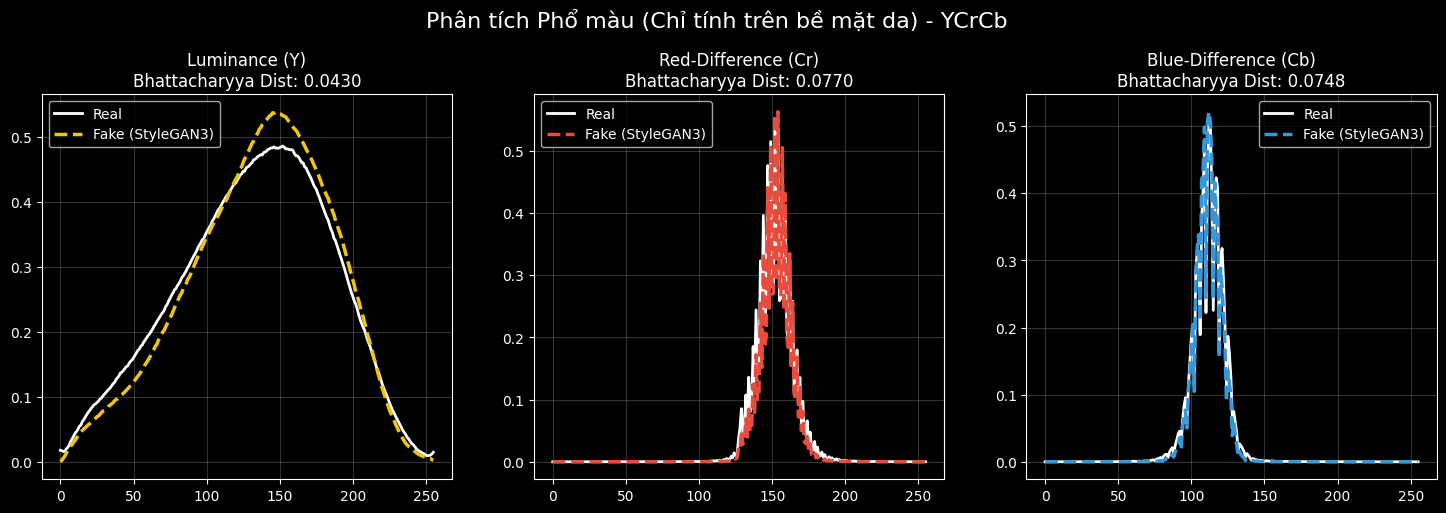

In [2]:
def compute_histograms(img_paths):
    avg_hist = [np.zeros((256, 1), dtype=np.float32) for _ in range(3)]
    valid_count = 0
    for path in tqdm(img_paths, desc="Computing YCrCb"):
        img = cv2.imread(path)
        if img is None: continue
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        res = detector.detect(mp_image)
        if not res.face_landmarks: continue
        
        h, w, _ = img.shape
        points = np.array([[int(l.x * w), int(l.y * h)] for l in res.face_landmarks[0]], dtype=np.int32)
        hull = cv2.convexHull(points)
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillConvexPoly(mask, hull, 255)
        
        img_ycc = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        valid_count += 1
        for i in range(3):
            hist = cv2.calcHist([img_ycc], [i], mask, [256], [0, 256])
            cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
            avg_hist[i] += hist
            
    for i in range(3):
        if valid_count > 0: avg_hist[i] /= valid_count
    return avg_hist

real_ycc = compute_histograms(real_sample)
fake_ycc = compute_histograms(fake_sample)
detector.close()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
channels = ['Luminance (Y)', 'Red-Difference (Cr)', 'Blue-Difference (Cb)']
colors = ['#f1c40f', '#e74c3c', '#3498db']

for i in range(3):
    axes[i].plot(real_ycc[i], label='Real', color='white', linewidth=2)
    axes[i].plot(fake_ycc[i], label='Fake (StyleGAN3)', color=colors[i], linestyle='--', linewidth=2.5)
    
    # Tính Bhattacharyya Distance
    b_dist = cv2.compareHist(real_ycc[i], fake_ycc[i], cv2.HISTCMP_BHATTACHARYYA)
    
    axes[i].set_title(f'{channels[i]}\nBhattacharyya Dist: {b_dist:.4f}', fontsize=12)
    axes[i].legend()
    axes[i].grid(alpha=0.2)

# Xuất số liệu phổ màu ra CSV
import pandas as pd
hist_data = {}
for i, channel in enumerate(['Y', 'Cr', 'Cb']):
    hist_data[f'{channel}_Real'] = real_ycc[i].flatten()
    hist_data[f'{channel}_Fake'] = fake_ycc[i].flatten()
pd.DataFrame(hist_data).to_csv('color_histogram_data.csv', index_label='Pixel_Value')
print("Đã xuất số liệu Phổ màu ra file: color_histogram_data.csv")

plt.suptitle("Phân tích Phổ màu (Chỉ tính trên bề mặt da) - YCrCb", fontsize=16, y=1.05)
plt.show()
